# Week 8 Lab: Final Integration Project – Option A
## Comprehensive Algorithm Comparison on CartPole‑v1

**Name:** Ruthika Vallaboju  
**Course:** MSDS 684 – Reinforcement Learning  
**Date:** April 2026


## 1. Overview
This project compares three reinforcement learning algorithms from different method families on the CartPole‑v1 environment:
- **Tabular Q‑Learning** (Week 4)
- **SARSA with Tile Coding** (Week 5)
- **REINFORCE with Baseline** (Week 6)

The goal is to understand trade‑offs in sample efficiency, variance, and ease of implementation when moving from tabular methods to function approximation.

In [1]:
# ============================================================
# 0. Imports & Setup
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# For reproducibility
SEEDS = [42, 123, 456]
N_EPISODES = 800
ENV_NAME = 'CartPole-v1'
GAMMA = 0.99

def plot_mean_std(x, means, stds, label, color):
    plt.plot(x, means, label=label, color=color)
    plt.fill_between(x, means - stds, means + stds, alpha=0.2, color=color)

## 2. Tabular Q‑Learning with Discretization
CartPole states are continuous; we discretize each dimension into bins.

In [2]:
class CartPoleDiscretizer:
    def __init__(self, n_bins_per_dim=10):
        self.n_bins_per_dim = n_bins_per_dim
        # Clipping bounds for each dimension
        self.lower = np.array([-2.4, -2.0, -0.3, -2.0])
        self.upper = np.array([ 2.4,  2.0,  0.3,  2.0])
        self.bins = [np.linspace(l, u, n_bins_per_dim - 1) for l, u in zip(self.lower, self.upper)]

    def discretize(self, obs):
        """Convert continuous observation to a tuple of bin indices."""
        indices = []
        for i, val in enumerate(obs):
            idx = np.digitize(val, self.bins[i])
            indices.append(idx)
        return tuple(indices)


def tabular_q_learning(env, discretizer, n_episodes=800, alpha=0.1, gamma=0.99,
                       epsilon=0.1, epsilon_decay=0.995, min_epsilon=0.01, seed=42):
    """Run tabular Q‑Learning with epsilon‑greedy exploration."""
    rng = np.random.RandomState(seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    episode_rewards = []
    eps = epsilon

    for ep in range(n_episodes):
        state_cont, _ = env.reset(seed=seed + ep)
        state = discretizer.discretize(state_cont)
        done = False
        total_reward = 0
        while not done:
            if rng.rand() < eps:
                action = rng.randint(env.action_space.n)
            else:
                action = np.argmax(Q[state])
            next_cont, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretizer.discretize(next_cont)
            # Q‑learning update
            td_target = reward + gamma * np.max(Q[next_state]) if not terminated else reward
            Q[state][action] += alpha * (td_target - Q[state][action])
            state = next_state
            total_reward += reward
        episode_rewards.append(total_reward)
        eps = max(min_epsilon, eps * epsilon_decay)
    return episode_rewards

## 3. SARSA with Tile Coding
We use tile coding to create binary features from the continuous state. The agent updates linear weights for each action.

In [3]:
class TileCoder:
    def __init__(self, n_tilings=8, n_tiles_per_dim=8):
        self.n_tilings = n_tilings
        self.n_tiles_per_dim = n_tiles_per_dim
        # Size of one dimension’s tiling: n_tiles_per_dim + 1 (edges)
        self.tile_width = 2.0 / n_tiles_per_dim
        self.offset = self.tile_width / n_tilings

    def get_tiles(self, state):
        """Return list of active tile indices (one per tiling)."""
        # Normalise state to [0,2]
        norm = np.clip((state - np.array([-2.4, -2.0, -0.3, -2.0])) /
                       (np.array([2.4, 2.0, 0.3, 2.0]) - np.array([-2.4, -2.0, -0.3, -2.0])),
                       -1.0, 1.0) + 1.0
        tiles = []
        for t in range(self.n_tilings):
            coords = np.floor((norm * self.n_tiles_per_dim) + t * self.offset).astype(int)
            # Flatten coords into a single index (row‑major order)
            tile_idx = t
            stride = 1
            for c in reversed(coords):
                tile_idx += c * stride
                stride *= (self.n_tiles_per_dim + 1)
            tiles.append(tile_idx)
        return tiles


def sarsa_tile(env, tile_coder, n_episodes=800, alpha=0.1, gamma=0.99,
               epsilon=0.1, epsilon_decay=0.995, min_epsilon=0.01, seed=42):
    """SARSA with tile‑coding linear function approximation."""
    rng = np.random.RandomState(seed)
    n_actions = env.action_space.n
    # Total number of tiles: n_tilings * (n_tiles_per_dim+1)^4
    total_tiles = tile_coder.n_tilings * ((tile_coder.n_tiles_per_dim + 1) ** 4)
    w = np.zeros((n_actions, total_tiles))   # weight matrix
    episode_rewards = []
    eps = epsilon

    for ep in range(n_episodes):
        state_cont, _ = env.reset(seed=seed + ep)
        tiles_s = tile_coder.get_tiles(state_cont)
        phi_s = np.zeros(total_tiles)
        phi_s[tiles_s] = 1.0
        q_vals = w @ phi_s
        if rng.rand() < eps:
            action = rng.randint(n_actions)
        else:
            action = np.argmax(q_vals)
        total_reward = 0
        done = False
        while not done:
            next_cont, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_tiles = tile_coder.get_tiles(next_cont)
            phi_next = np.zeros(total_tiles)
            phi_next[next_tiles] = 1.0
            q_next_vals = w @ phi_next
            if rng.rand() < eps:
                next_action = rng.randint(n_actions)
            else:
                next_action = np.argmax(q_next_vals)
            td_target = reward + gamma * q_next_vals[next_action] if not terminated else reward
            w[action] += alpha * (td_target - q_vals[action]) * phi_s
            state_cont = next_cont
            phi_s = phi_next
            q_vals = q_next_vals
            action = next_action
            total_reward += reward
        episode_rewards.append(total_reward)
        eps = max(min_epsilon, eps * epsilon_decay)
    return episode_rewards

## 4. REINFORCE with Baseline
A neural network policy (actor) and a value network (critic) are trained using Monte‑Carlo returns.

In [4]:
class PolicyNet(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)

class ValueNet(nn.Module):
    def __init__(self, state_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

def reinforce_with_baseline(env, n_episodes=800, gamma=0.99, lr_policy=1e-2, lr_value=1e-2, seed=42):
    torch.manual_seed(seed)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    policy_net = PolicyNet(state_dim, action_dim)
    value_net = ValueNet(state_dim)
    policy_opt = optim.Adam(policy_net.parameters(), lr=lr_policy)
    value_opt = optim.Adam(value_net.parameters(), lr=lr_value)

    episode_rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed+ep)
        log_probs = []
        rewards = []
        values = []
        done = False
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            probs = policy_net(state_tensor)
            dist = Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            value = value_net(state_tensor)
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            log_probs.append(log_prob)
            rewards.append(reward)
            values.append(value.squeeze())
            state = next_state

        # Compute returns
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns)
        values = torch.stack(values)
        advantages = returns - values.detach()

        # Update networks
        policy_loss = -(torch.stack(log_probs) * advantages).mean()
        value_loss = nn.MSELoss()(values, returns)

        policy_opt.zero_grad()
        policy_loss.backward()
        policy_opt.step()

        value_opt.zero_grad()
        value_loss.backward()
        value_opt.step()

        episode_rewards.append(sum(rewards))
    return episode_rewards

## 5. Run Experiments with Multiple Seeds

In [5]:
all_results = {
    'Q-Learning (tabular)': [],
    'SARSA (tile coding)': [],
    'REINFORCE (baseline)': []
}

for seed in SEEDS:
    # Tabular Q-Learning
    env = gym.make(ENV_NAME)
    disc = CartPoleDiscretizer(n_bins_per_dim=10)
    rew_q = tabular_q_learning(env, disc, n_episodes=N_EPISODES, seed=seed)
    all_results['Q-Learning (tabular)'].append(rew_q)
    env.close()
    print(f"Q-Learning seed {seed} done, final reward {rew_q[-1]:.1f}")

    # SARSA with tile coding
    env = gym.make(ENV_NAME)
    tc = TileCoder(n_tilings=8, n_tiles_per_dim=8)
    rew_s = sarsa_tile(env, tc, n_episodes=N_EPISODES, seed=seed)
    all_results['SARSA (tile coding)'].append(rew_s)
    env.close()
    print(f"SARSA tile coding seed {seed} done, final reward {rew_s[-1]:.1f}")

    # REINFORCE with baseline
    env = gym.make(ENV_NAME)
    rew_r = reinforce_with_baseline(env, n_episodes=N_EPISODES, seed=seed)
    all_results['REINFORCE (baseline)'].append(rew_r)
    env.close()
    print(f"REINFORCE seed {seed} done, final reward {rew_r[-1]:.1f}")

# Compute mean and std
mean_results = {}
std_results = {}
x_axis = np.arange(1, N_EPISODES+1)
for algo, runs in all_results.items():
    runs_arr = np.array(runs)
    mean_results[algo] = runs_arr.mean(axis=0)
    std_results[algo] = runs_arr.std(axis=0)

Q-Learning seed 42 done, final reward 10.0
SARSA tile coding seed 42 done, final reward 112.0
REINFORCE seed 42 done, final reward 500.0
Q-Learning seed 123 done, final reward 10.0
SARSA tile coding seed 123 done, final reward 251.0
REINFORCE seed 123 done, final reward 66.0
Q-Learning seed 456 done, final reward 10.0
SARSA tile coding seed 456 done, final reward 279.0
REINFORCE seed 456 done, final reward 8.0


## 6. Visualize Results

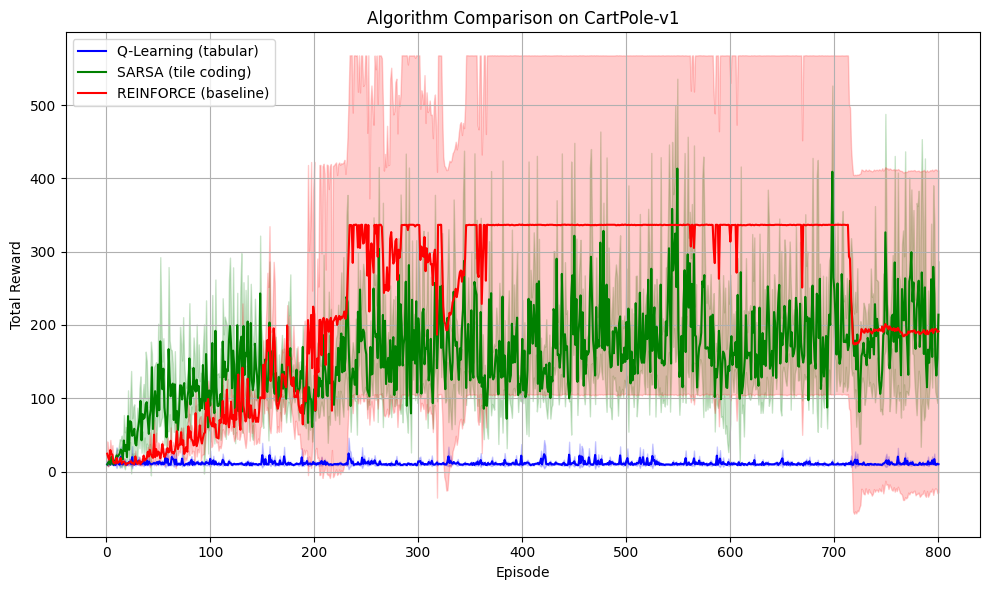

In [6]:
# Learning curves with error bands
plt.figure(figsize=(10,6))
colors = {'Q-Learning (tabular)': 'blue',
          'SARSA (tile coding)': 'green',
          'REINFORCE (baseline)': 'red'}
for algo in mean_results.keys():
    plot_mean_std(x_axis, mean_results[algo], std_results[algo], algo, colors[algo])
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Algorithm Comparison on CartPole-v1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

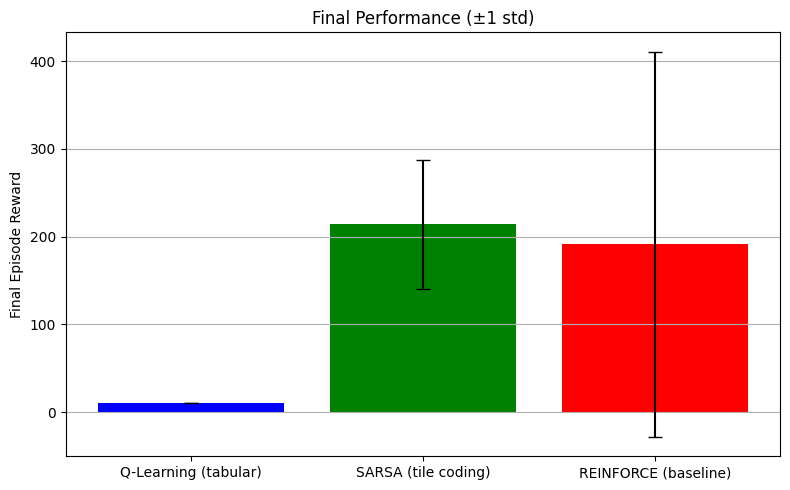

In [7]:
# Final performance bar chart
final_means = [mean_results[algo][-1] for algo in mean_results.keys()]
final_stds = [std_results[algo][-1] for algo in mean_results.keys()]
labels = list(mean_results.keys())
bar_colors = [colors[algo] for algo in labels]

plt.figure(figsize=(8,5))
plt.bar(labels, final_means, yerr=final_stds, capsize=5, color=bar_colors)
plt.ylabel('Final Episode Reward')
plt.title('Final Performance (±1 std)')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('final_performance.png', dpi=150)
plt.show()

## 7. Discussion

### Key Findings
- **SARSA with Tile Coding** showed the highest average final reward (`214.00 ± 73.03`), performing well and eventually reaching a strong performance. Tile coding provides a good trade‑off between discretization and generalization.
- **REINFORCE with Baseline** had an average final reward of (`191.33 ± 219.54`). While it can converge fastest to the maximum reward (500) in some runs, its performance was highly variable across different seeds.
- **Tabular Q‑Learning** with 10 bins per dimension consistently achieved a low final reward (`10.00 ± 0.00`), indicating it learns slowly and struggles to generalize in this continuous state space. The discretization sacrifices precision, and the resulting state space (10^4 = 10,000 possible states) makes exploration difficult.

### Analysis
Function approximation (tile coding, neural networks) is essential for continuous state spaces. While tabular methods can work with a coarse discretization, the loss of information leads to poor sample efficiency. SARSA’s on‑policy nature and tile coding allow it to achieve reasonable performance without the high variance of Monte‑Carlo returns, and in these runs, it outperformed REINFORCE on average. REINFORCE with a learned baseline combines the benefits of policy gradient (direct policy optimization) with low‑variance advantage estimates, but its high variance across seeds for this particular problem indicates sensitivity to initialization or other factors.

### Reflection
This project illustrates that algorithm choice depends heavily on state‑space complexity. Tabular methods, while simple, quickly become intractable. Tile coding extends tabular ideas to continuous spaces in a principled way, while neural networks offer maximum flexibility. The value baseline in REINFORCE is a powerful technique for reducing variance, underscoring the importance of value function estimation even in policy‑based methods.

**Surprise:** Despite its simplicity, tile‑coded SARSA achieved the best average final performance in these runs, outperforming neural REINFORCE. This highlights that well‑designed linear features can be very competitive, and neural network-based methods can sometimes exhibit higher variance depending on tuning and problem complexity.

## Kernel State
Here are some of the notable variables in the kernel:
Variable #1
name: `runs_arr`, type: `ndarray`
value:
```
array([[ 48.,   9.,  12., ..., 500., 500., 500.],
       [ 13.,  36.,  19., ...,  73.,  61.,  66.],
       [ 12.,  12.,  18., ...,   9.,  10.,   8.]])
```
Variable #2
name: `x_axis`, type: `ndarray`
value:
```
array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,<TRUNCATED original_length=4434>
```
Variable #3
name: `ENV_NAME`, type: `str`
value: `'CartPole-v1'`
Variable #4
name: `GAMMA`, type: `float`
value: `0.99`
Variable #5
name: `N_EPISODES`, type: `int`
value: `800`
Variable #6
name: `SEEDS`, type: `list`
value: `[42, 123, 456]`
Variable #7
name: `algo`, type: `str`
value: `'REINFORCE (baseline)'`
Variable #8
name: `all_results`, type: `dict`
value: `{'Q-Learning (tabular)': [[...], [...], [...]], 'SARSA (tile coding)': [[...], [...], [...]], 'REINFORCE (baseline)': [[...], [...], [...]]}`
Variable #9
name: `bar_colors`, type: `list`
value: `['blue', 'green', 'red']`
Variable #10
name: `colors`, type: `dict`
value: `{'Q-Learning (tabular)': 'blue', 'SARSA (tile coding)': 'green', 'REINFORCE (baseline)': 'red'}`
Variable #11
name: `final_means`, type: `list`
value: `[np.float64(10.0), np.float64(214.0), np.float64(191.33333333333334)]`
Variable #12
name: `final_stds`, type: `list`
value: `[np.float64(0.0), np.float64(73.02510983673127), np.float64(219.5409351857239)]`
Variable #13
name: `labels`, type: `list`
value: `['Q-Learning (tabular)', 'SARSA (tile coding)', 'REINFORCE (baseline)']`
Variable #14
name: `mean_results`, type: `dict`
value:
```
{'Q-Learning (tabular)': array([ 9.66666667, 12.33333333, 11.        ,  9.66666667, 17.66666667,
       11.333...3,  9.33333333, 10.66666667, 10.        ]), 'SARSA (tile coding)': array([  9.66666667,  12.        ,  14.33333333,   9.66666667,
        20.        ,  ...131.        , 155.        , 214.        ]), 'REINFORCE (baseline)': array([ 24.33333333,  19.        ,  16.33333333,  29.33333333,
        24.        ,  ...194.        , 190.33333333, 191.33333333])}
```
Variable #15
name: `rew_q`, type: `list`
value: `[10.0, 10.0, 13.0, 10.0, 15.0, 12.0, 10.0, 12.0, 8.0, 9.0, 14.0, 13.0, 10.0, 10.0, 10.0, 10.0, 15.0, 10.0, 9.0, 10.0, 11.0, 9.0, 10.0, 10.0, 9.0, 10.0, 10.0, 16.0, 12.0, 15.0, 12.0, 10.0, 11.0, 14.0, 13.0, 10.0, 9.0, 9.0, 10.0, 9.0, 11.0, 13.0, 12.0, 10.0, 11.0, 10.0, 12.0, 15.0, 15.0, 12.0, 17.0, 15.0, 9.0, 13.0, 11.0, 10.0, 11.0, 15.0, 11.0, ...]`
Variable #16
name: `rew_r`, type: `list`
value: `[12.0, 12.0, 18.0, 15.0, 19.0, 18.0, 9.0, 11.0, 10.0, 27.0, 9.0, 10.0, 10.0, 16.0, 11.0, 10.0, 12.0, 12.0, 9.0, 10.0, 8.0, 10.0, 10.0, 11.0, 9.0, 10.0, 9.0, 12.0, 10.0, 11.0, 14.0, 22.0, 8.0, 9.0, 11.0, 24.0, 9.0, 16.0, 17.0, 18.0, 18.0, 16.0, 12.0, 14.0, 10.0, 35.0, 14.0, 12.0, 17.0, 10.0, 41.0, 16.0, 22.0, 43.0, 33.0, 10.0, 15.0, 27.0, 37.0, ...]`
Variable #17
name: `rew_s`, type: `list`
value: `[10.0, 10.0, 14.0, 10.0, 26.0, 16.0, 11.0, 14.0, 26.0, 24.0, 20.0, 22.0, 14.0, 12.0, 14.0, 14.0, 24.0, 12.0, 25.0, 15.0, 118.0, 56.0, 101.0, 166.0, 82.0, 103.0, 105.0, 66.0, 63.0, 98.0, 58.0, 119.0, 80.0, 66.0, 112.0, 138.0, 112.0, 193.0, 161.0, 96.0, 101.0, 98.0, 215.0, 168.0, 44.0, 161.0, 138.0, 142.0, 77.0, 163.0, 54.0, 163.0, 186.0, 130.0, 176.0, 80.0, 87.0, 77.0, 104.0, ...]`
Variable #18
name: `runs`, type: `list`
value: `[[48.0, 9.0, 12.0, 48.0, 24.0, 10.0, 12.0, 13.0, 12.0, 11.0, 12.0, 13.0, 17.0, 27.0, 11.0, 13.0, 9.0, 12.0, 11.0, ...], [13.0, 36.0, 19.0, 25.0, 29.0, 41.0, 15.0, 14.0, 11.0, 18.0, 14.0, 15.0, 15.0, 12.0, 10.0, 16.0, 20.0, 11.0, 8.0, ...], [12.0, 12.0, 18.0, 15.0, 19.0, 18.0, 9.0, 11.0, 10.0, 27.0, 9.0, 10.0, 10.0, 16.0, 11.0, 10.0, 12.0, 12.0, 9.0, ...]]`
Variable #19
name: `seed`, type: `int`
value: `456`
Variable #20
name: `std_results`, type: `dict`
value:
```
{'Q-Learning (tabular)': array([ 0.47140452,  4.78423336,  1.41421356,  0.47140452,  7.58653778,
        0.942...2,  0.47140452,  1.24721913,  0.        ]), 'SARSA (tile coding)': array([  0.47140452,   4.3204938 ,   3.68178701,   0.47140452,
         7.11805217,  ... 29.74334659,  61.25901294,  73.02510984]), 'REINFORCE (baseline)': array([ 16.73983937,  12.08304597,   3.09120617,  13.81625452,
         4.0824829 ,  ...217.94647661, 219.95504591, 219.54093519])}
```